¡Dataset cargado con éxito!
El heatmap ha sido exportado y guardado correctamente como 'heatmap_eeg.png' a 300 DPI.


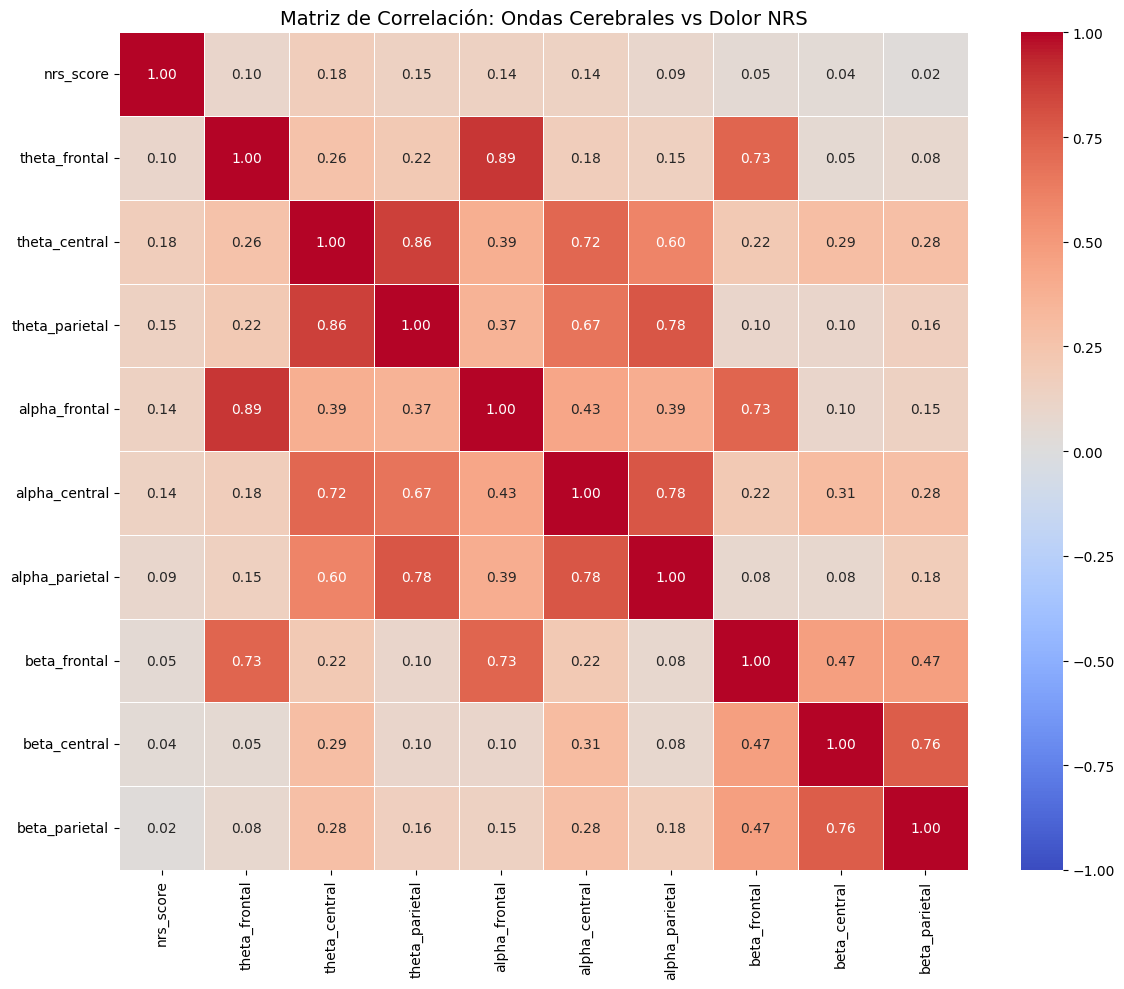

In [1]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# ==========================================
# 1. CARGA DEL DATASET DESDE GOOGLE COLAB
# ==========================================
# Si usas Google Drive, descomenta las siguientes dos líneas:
# from google.colab import drive
# drive.mount('/content/drive')

# NOTA: Reemplaza con tu ruta real del archivo
ruta_archivo = "/content/dataset_features_eeg.csv"

if os.path.exists(ruta_archivo):
    df_eeg = pd.read_csv(ruta_archivo)
    print("¡Dataset cargado con éxito!")
else:
    print(
        f"Error: No se encontró el archivo en la ruta {ruta_archivo}. "
        "Por favor, verifica la ruta en tu Drive."
    )

# ==========================================
# 2. DEFINICIÓN DE VARIABLES (BANDAS Y ZONAS)
# ==========================================
bandas = [
    "theta_frontal",
    "theta_central",
    "theta_parietal",
    "alpha_frontal",
    "alpha_central",
    "alpha_parietal",
    "beta_frontal",
    "beta_central",
    "beta_parietal",
]

target = "nrs_score"

# ==========================================
# 3. TRANSFORMACIÓN LOGARÍTMICA PREVENTIVA
# ==========================================
# Creamos una copia para no modificar el dataset original
df_log = df_eeg.copy()

# Aplicamos log10 sumando un valor infinitesimal (1e-9) para evitar
# errores matemáticos si existen valores iguales a 0 (indefinición).
for b in bandas:
    df_log[b] = np.log10(df_eeg[b] + 1e-9)

# ==========================================
# 4. CÁLCULO DE LA MATRIZ DE CORRELACIÓN
# ==========================================
# Filtramos solo las columnas de interés para el análisis
columnas_finales = [target] + bandas
matriz_eeg = df_log[columnas_finales].corr(method="pearson")

# ==========================================
# 5. GRAFICAR Y EXPORTAR EL HEATMAP
# ==========================================
plt.figure(figsize=(12, 10))

# Usamos una máscara para que sea más fácil concentrarse en la fila de 'nrs_score'
# u opcionalmente dejamos la matriz completa.
sns.heatmap(
    matriz_eeg,
    annot=True,  # Muestra los valores numéricos
    cmap="coolwarm",  # Azul (negativo), Blanco (cero), Rojo (positivo)
    fmt=".2f",  # Dos decimales
    vmin=-1,
    vmax=1,  # Rango estricto de Pearson
    linewidths=0.5,  # Separación elegante entre celdas
    linecolor="white",
)

plt.title("Matriz de Correlación: Ondas Cerebrales vs Dolor NRS", fontsize=14)
plt.tight_layout()

# EXPORTACIÓN AUTOMÁTICA EN ALTA DEFINICIÓN (Requisito de la tarea)
plt.savefig("heatmap_eeg.png", dpi=300)
print(
    "El heatmap ha sido exportado y guardado correctamente como 'heatmap_eeg.png' a 300 DPI."
)

plt.show()